In [18]:
from dotenv import load_dotenv

load_dotenv(dotenv_path=".env", override=True)

import os
import uuid
from typing import Annotated, Optional

import gradio as gr
from IPython.display import Image, Markdown, display
from langchain.tools import tool
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt
from langsmith.utils import get_env_var, get_tracer_project
from pydantic import BaseModel, Field

get_env_var.cache_clear()
get_tracer_project.cache_clear()

if not os.getenv("LANGSMITH_API_KEY"):
    raise RuntimeError("LANGSMITH_API_KEY missing after load_dotenv")
if os.getenv("LANGSMITH_TRACING", "").lower() != "true":
    raise RuntimeError("Set LANGSMITH_TRACING=true in .env")

print(
    f"LangSmith: project={os.getenv('LANGSMITH_PROJECT')!r} "
    f"endpoint={os.getenv('LANGSMITH_ENDPOINT')!r}"
)


LangSmith: project='AgentBridge' endpoint='https://eu.api.smith.langchain.com'


#### Define constants and system prompt

In [38]:
agent_name = "Framework Chooser"

input_check_system_prompt = """
You are an input-check node for an AI agent/RAG framework chooser.
Decide if the user provided enough information to recommend a framework.

A valid input must include:
1. A clear framework-selection question or goal
2. Client/company context
3. Tech stack or platform constraints
4. Required data sources/integrations
5. Security/compliance/privacy constraints
6. Team/ownership constraints
7. Expected workflow or agent task

The context may be inside the same user message as the question.
If anything is missing, ask only the minimum follow-up questions.
Ask max 5 questions.
Group missing info into short, clear questions.
"""

choose_framework_system_prompt = """
You are Framework Chooser, an expert on AI agent and RAG frameworks.

You MUST NOT answer framework recommendation questions from memory only.

Before recommending a framework, use search_web for current information. Rules:
- Make at most 2 search_web calls per user message (one broad query, then one follow-up if needed).
- Combine topics into a single query when possible.
- After you have enough search results, stop calling tools and write your final answer.

When you stop calling tools, respond in Markdown with EXACTLY these sections (use these headings):

## Recommendation
Primary framework choice, 1–2 alternates, and why they fit the client case.

## Sources
List every source you relied on from search_web results. For each source use:
- **[Title](URL)** — one sentence on what it supported in your recommendation.
Only cite URLs that appeared in search_web output. Do not invent links.

## Risks
3–5 concrete risks for this client (integration, security, ops, vendor lock-in, hallucination, human-in-the-loop gaps, etc.).
For each risk: **Risk** | **Impact** (Low/Medium/High) | **Mitigation**.

## PoC metrics
Define how to validate the choice in a 2–4 week proof of concept. Include a small table or bullet list with:
- **Metric** — what you measure
- **Target** — numeric or clear pass/fail threshold
- **How to measure** — tool, test, or workflow

Choose metrics that match the client's actual use case, data sources, integrations, team constraints, and approval workflow. Do not assume specific tools such as Notion, Postgres, Zendesk, Slack, Salesforce, or Jira unless they appear in the client context.

Cover at least these generic validation areas, adapting the wording to the client case:
- time-to-first-working-agent or time-to-first-useful-workflow
- source/data ingestion quality for the client's actual documents, systems, or knowledge bases
- retrieval or tool-call accuracy for the client's actual data/API/tool surfaces
- output acceptance quality for the client's target workflow, such as answers, drafts, actions, reports, tickets, or recommendations
- human review or approval latency if human-in-the-loop is relevant
- safety, permissions, and failure-mode handling for the client's environment
- estimated PoC infrastructure and operating cost
"""

#### Define llm

In [21]:
llm = ChatOpenAI(model="gpt-5-nano", timeout=45, max_retries=1)

#### Define State

In [22]:
class AgentBridgeState(BaseModel):
    messages: Annotated[list, add_messages] = Field(default_factory=list)

    user_question: Optional[str] = None
    platform_description: Optional[str] = None
    uploaded_document_ids: list[str] = Field(default_factory=list)

    input_check_passed: bool = False
    missing_items: list[str] = Field(default_factory=list)


#### Helpers

In [23]:
def get_user_question(state: AgentBridgeState) -> str | None:
    if state.user_question:
        return state.user_question

    for message in reversed(state.messages):
        role = getattr(message, "type", None) or getattr(message, "role", None)
        if role in {"human", "user"}:
            return message.content

    return None


class InputCheckResult(BaseModel):
    can_continue: bool = Field(
        description="True when there is enough information to continue to framework recommendation."
    )
    user_question: Optional[str] = Field(
        default=None,
        description="The user's framework-selection question, cleaned up if needed."
    )
    platform_description: Optional[str] = Field(
        default=None,
        description="Relevant client/platform context found in the user input."
    )
    missing_items: list[str] = Field(default_factory=list)
    questions: list[str] = Field(default_factory=list)


def make_graph_config(thread_id: str | None = None) -> dict:
    return {
        "configurable": {
            "thread_id": thread_id or f"agentbridge-{uuid.uuid4().hex}"
        },
        "recursion_limit": 9,
    }


def get_interrupt_payload(result: dict) -> dict | None:
    interrupts = result.get("__interrupt__") or []
    if not interrupts:
        return None

    return interrupts[0].value


def format_interrupt_payload(payload: dict) -> str:
    questions = payload.get("questions", [])
    question_block = "\n".join(f"- {question}" for question in questions)
    return f"{payload.get('message', 'I need more information.')}\n\n{question_block}".strip()


def format_graph_result(result: dict) -> str:
    if payload := get_interrupt_payload(result):
        return format_interrupt_payload(payload)

    messages = result.get("messages") or []
    if not messages:
        return "The graph finished without producing a message."

    return messages[-1].content


#### Input check Node

In [39]:
input_check_model = llm.with_structured_output(InputCheckResult)

def input_check_node(state: AgentBridgeState) -> dict:
    user_input = get_user_question(state) or ""
    platform_context = state.platform_description or ""

    while True:
        result = input_check_model.invoke(
            [
                SystemMessage(content=input_check_system_prompt),
                HumanMessage(
                    content=(
                        f"User input:\n{user_input}\n\n"
                        f"Known platform context:\n{platform_context or '<none>'}\n\n"
                        f"Uploaded document ids: {state.uploaded_document_ids}"
                    )
                ),
            ]
        )

        if result.can_continue:
            return {
                "user_question": result.user_question or user_input,
                "platform_description": result.platform_description or platform_context,
                "input_check_passed": True,
                "missing_items": [],
            }

        human_answer = interrupt(
            {
                "type": "input_check_missing_information",
                "message": "I need more information before starting the analysis.",
                "missing_items": result.missing_items,
                "questions": result.questions,
            }
        )

        user_input = f"{user_input}\n\nUser clarification:\n{human_answer}"


In [25]:
def route_after_input_check(state: AgentBridgeState) -> str:
    if state.input_check_passed:
        return "choose_framework"

    return END

#### Search tool and helper for it

In [26]:
serper = GoogleSerperAPIWrapper(k=5)


def _format_search_results(results: dict, query: str) -> str:
    lines = [f"Query: {query}", ""]

    if answer_box := results.get("answerBox"):
        if answer := answer_box.get("answer"):
            lines.extend(["Answer box:", answer, ""])
        elif snippet := answer_box.get("snippet"):
            lines.extend(["Answer box:", snippet.replace("\n", " "), ""])
        if link := answer_box.get("link"):
            lines.append(f"Source: {link}")
            lines.append("")

    if kg := results.get("knowledgeGraph"):
        title = kg.get("title", "Knowledge graph")
        if description := kg.get("description"):
            lines.extend([f"{title}:", description, ""])
        if link := kg.get("website") or kg.get("descriptionLink"):
            lines.append(f"Source: {link}")
            lines.append("")

    organic = results.get("organic", [])[: serper.k]
    if organic:
        lines.append("Search results:")
        for i, item in enumerate(organic, 1):
            title = item.get("title", "Untitled")
            link = item.get("link", "")
            snippet = item.get("snippet", "").replace("\n", " ")
            lines.extend(
                [
                    f"[{i}] {title}",
                    f"URL: {link}",
                    f"Snippet: {snippet}",
                    "",
                ]
            )
    elif len(lines) == 2:
        lines.append("No search results found.")

    return "\n".join(lines)


@tool
def search_web(query: str) -> str:
    """Search the web for current information. Returns titles, URLs, and snippets to cite as sources."""
    results = serper.results(query)
    return _format_search_results(results, query)


llm = llm.bind_tools([search_web])


#### Choose framework Node

In [27]:
def choose_framework(old_state: AgentBridgeState) -> dict:
    messages = [SystemMessage(content=choose_framework_system_prompt)]

    if old_state.platform_description:
        messages.append(
            SystemMessage(
                content=(
                    "Client/platform context supplied during input check:\n"
                    f"{old_state.platform_description}"
                )
            )
        )

    messages.extend(old_state.messages)

    if old_state.user_question and not old_state.messages:
        messages.append(HumanMessage(content=old_state.user_question))

    response = llm.invoke(messages)
    return {"messages": [response]}


#### Create Graph Builder + memory + add Nodes and Edges

In [40]:
memory = MemorySaver()

graph_builder = StateGraph(AgentBridgeState)

graph_builder.add_node("input_check", input_check_node)
graph_builder.add_node("choose_framework", choose_framework)
graph_builder.add_node("tools", ToolNode([search_web]))

In [41]:
graph_builder.add_edge(START, "input_check")
graph_builder.add_conditional_edges(
    "input_check",
    route_after_input_check,
    {
        "choose_framework": "choose_framework",
        END: END,
    },
)
graph_builder.add_conditional_edges(
    "choose_framework",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    },
)
graph_builder.add_edge("tools", "choose_framework")


#### Compile graph with memory (checkpointer)

In [42]:
graph = graph_builder.compile(checkpointer=memory)


#### Display mermaid diagram of our Graph

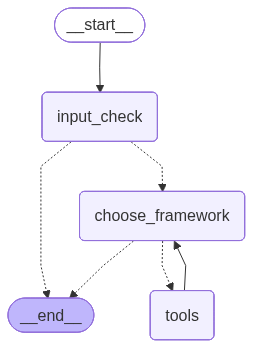

In [43]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Use in terminal

In [66]:
# question = "What is the best framework for building an agent?"

# terminal_config = make_graph_config("agentbridge-terminal-demo")
# state = AgentBridgeState(
#     messages=[HumanMessage(content=question)],
#     user_question=question,
#     platform_description=None,
#     uploaded_document_ids=[],
# )

# result = graph.invoke(state, config=terminal_config)
# Markdown(format_graph_result(result))


#### Resume interrupted terminal run


In [67]:
# resume_payload = {
#     "platform_description": (
#         "Notebook-based research assistant for comparing AI agent and RAG frameworks. "
#         "It should ingest product docs, use web research for current framework information, "
#         "and produce a framework recommendation with risks and PoC metrics."
#     )
# }

# result = graph.invoke(Command(resume=resume_payload), config=terminal_config)
# Markdown(format_graph_result(result))


## Use in Gradio

In [44]:
def build_gradio_resume_payload(user_input: str, pending_interrupt: dict) -> dict:
    missing_items = pending_interrupt.get("missing_items", []) if pending_interrupt else []

    if "user_question" in missing_items:
        return {"user_question": user_input}

    if "platform_description_or_uploaded_docs" in missing_items:
        return {"platform_description": user_input}

    if "ai_agent_or_rag_related_question" in missing_items:
        return {"answer": user_input}

    return {"answer": user_input}


def flush_langsmith_traces() -> None:
    try:
        from langsmith import Client

        client = Client()
        if hasattr(client, "flush"):
            client.flush()
    except Exception:
        pass


def gradio_respond(user_input: str, history, thread_id: str | None, pending_interrupt):
    user_input = (user_input or "").strip()
    history = history or []
    thread_id = thread_id or f"agentbridge-gradio-{uuid.uuid4().hex}"

    if not user_input:
        return "", history, thread_id, pending_interrupt

    history.append({"role": "user", "content": user_input})
    config = make_graph_config(thread_id)

    try:
        if pending_interrupt:
            result = graph.invoke(
                Command(resume=build_gradio_resume_payload(user_input, pending_interrupt)),
                config=config,
            )
        else:
            result = graph.invoke(
                AgentBridgeState(
                    messages=[HumanMessage(content=user_input)],
                    user_question=user_input,
                    platform_description=None,
                    uploaded_document_ids=[],
                ),
                config=config,
            )

        pending_interrupt = get_interrupt_payload(result)
        assistant_message = (
            format_interrupt_payload(pending_interrupt)
            if pending_interrupt
            else format_graph_result(result)
        )
    except Exception as exc:
        pending_interrupt = None
        assistant_message = f"Error while running graph: {exc}"
    finally:
        flush_langsmith_traces()

    history.append({"role": "assistant", "content": assistant_message})
    return "", history, thread_id, pending_interrupt


def gradio_reset():
    return [], f"agentbridge-gradio-{uuid.uuid4().hex}", None


with gr.Blocks() as demo:
    gr.Markdown("## AgentBridge Framework Chooser")
    gr.Markdown(
        "Ask a framework-selection question. If required context is missing, "
        "the graph interrupts and this UI resumes the same LangGraph thread after your answer."
    )

    chatbot = gr.Chatbot()
    user_box = gr.Textbox(
        label="Message",
        placeholder="Ask a framework question, then answer the follow-up if the graph interrupts.",
    )
    with gr.Row():
        send_button = gr.Button("Send", variant="primary")
        clear_button = gr.Button("New conversation")

    thread_state = gr.State(None)
    pending_interrupt_state = gr.State(None)

    user_box.submit(
        gradio_respond,
        inputs=[user_box, chatbot, thread_state, pending_interrupt_state],
        outputs=[user_box, chatbot, thread_state, pending_interrupt_state],
    )
    send_button.click(
        gradio_respond,
        inputs=[user_box, chatbot, thread_state, pending_interrupt_state],
        outputs=[user_box, chatbot, thread_state, pending_interrupt_state],
    )
    clear_button.click(
        gradio_reset,
        outputs=[chatbot, thread_state, pending_interrupt_state],
    )


demo.launch()


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
